c:\Users\USER\Desktop\droplet_ai\droplet_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM (NASA POWER) Test Set Performance:
  RMSE: 65.85
  MAE:  47.18
  MAPE: 31.80%
  R²:   0.6891

Feature importances:
  humidity_pct: 304.000
  lag_3: 230.000
  temp_min_C: 228.000
  lag_1: 199.000
  lag_2: 198.000
  pressure_kPa: 187.000
  temp_max_C: 166.000
  wind_speed_ms: 149.000
  year: 147.000
  temp_mean_C: 119.000
  month: 73.000


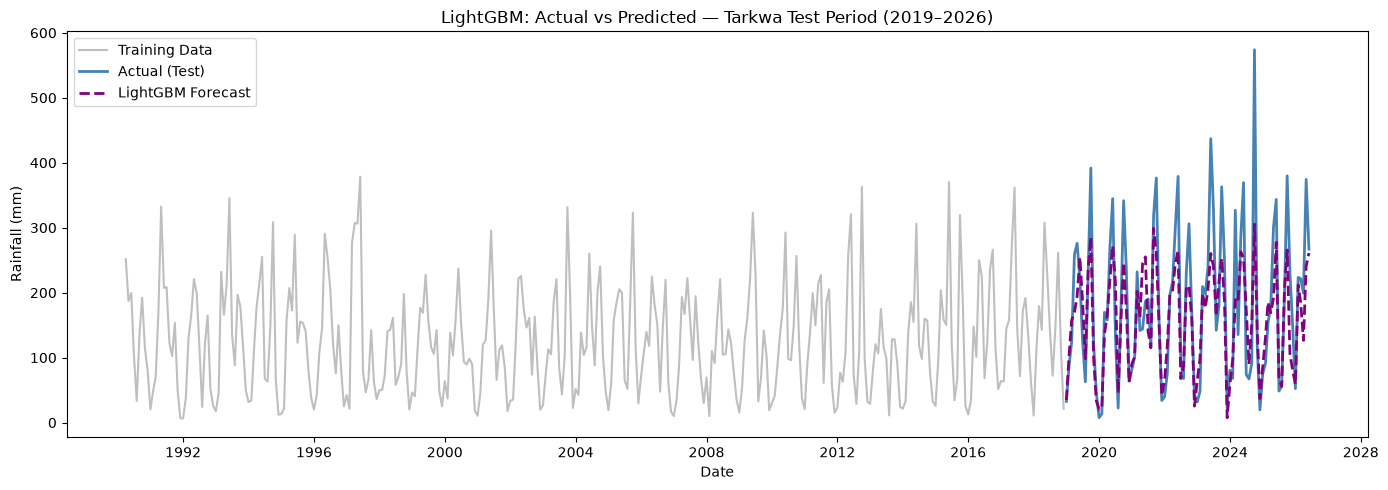


Model saved to ../models/nasa_lgbm_model.pkl
Reload check — first 3 predictions: [ 34.7 105.4 157.6]


c:\Users\USER\Desktop\droplet_ai\droplet_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

df = pd.read_csv("../data/tarkwa_nasa_monthly.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

df["lag_1"] = df["rainfall_mm"].shift(1)
df["lag_2"] = df["rainfall_mm"].shift(2)
df["lag_3"] = df["rainfall_mm"].shift(3)
df = df.dropna().reset_index(drop=True)

feature_cols = [
    "temp_mean_C", "temp_max_C", "temp_min_C",
    "humidity_pct", "pressure_kPa", "wind_speed_ms",
    "month", "year", "lag_1", "lag_2", "lag_3"
]

X = df[feature_cols].values
y = df["rainfall_mm"].values

split_date = "2019-01-01"
split_idx = df[df["date"] >= split_date].index[0]

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

lgbm_model = lgb.LGBMRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)

y_pred = lgbm_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print("LightGBM (NASA POWER) Test Set Performance:")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  MAPE: {mape:.2f}%")
print(f"  R²:   {r2:.4f}")

print("\nFeature importances:")
for feat, imp in sorted(zip(feature_cols, lgbm_model.feature_importances_),
                         key=lambda x: x[1], reverse=True):
    print(f"  {feat}: {imp:.3f}")

test_dates = df["date"].iloc[split_idx:].reset_index(drop=True)
train_dates = df["date"].iloc[:split_idx].reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(train_dates, y_train, label="Training Data", color="gray", alpha=0.5)
plt.plot(test_dates, y_test, label="Actual (Test)", color="steelblue", linewidth=2)
plt.plot(test_dates, y_pred, label="LightGBM Forecast", color="purple", linewidth=2, linestyle="--")
plt.title("LightGBM: Actual vs Predicted — Tarkwa Test Period (2019–2026)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.savefig("../models/nasa_lgbm_actual_vs_predicted.png", dpi=150)
plt.show()

MODEL_PATH = "../models/nasa_lgbm_model.pkl"
joblib.dump(lgbm_model, MODEL_PATH)
loaded = joblib.load(MODEL_PATH)
print(f"\nModel saved to {MODEL_PATH}")
print(f"Reload check — first 3 predictions: {loaded.predict(X_test[:3]).round(1)}")